# CLUSTERING DEL RIESGO ENERGÉTICO EN LAS ZNI

El presente cuaderno contiene el algoritmo no supervisado de Machine Learning para la identificación del riesgo energético en las *Zonas No Interconectadas*. Con el fin de focalizar la política pública, se agrupan los municipios según su consumo y sus horas de servicio, permitiendo observar de manera cuantitativa los distintos perfiles de riesgo.

**Objetivo:** identificar perfiles de riesgo energético mediante clustering (insumo para los lineamientos de política y el tablero de control).

**Modelo:** `K-means`

## Bibliotecas

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score

## Datos

In [3]:
df = pd.read_csv("../data/processed/servicio_electrico_limpio.csv")
df.head()

,id_departamento,departamento,id_municipio,municipio,id_localidad,localidad,anio_servicio,mes_servicio,energia_activa,energia_reactiva,potencia_maxima,dia_demanda_max,fecha_demanda_max,promedio_horas,municipio_original
0,91,amazonas,91001,leticia,91001000,leticia (leticia - amazonas),2020,1,3930642,1251191,7768.76,lunes,2020-01-27 14:15:00,24.00,leticia
1,91,amazonas,91540,puerto nariño,91540000,puerto nariño (puerto nariño - amazonas),2020,1,103897,36304,227.04,miércoles,2020-01-22 19:15:00,24.00,puerto nariño
2,91,amazonas,91798,tarapacá,91798000,tarapacá (tarapacá (anm) - amazonas),2020,1,22864,9277,88.96,jueves,2020-01-30 19:30:00,10.19,tarapacá (anm)
3,5,antioquia,5873,vigía del fuerte,5873001,san antonio de padua (vigía del fuerte - antio...,2020,1,5617,1381,53.66,jueves,2020-01-23 19:45:00,4.13,vigía del fuerte
4,5,antioquia,5873,vigía del fuerte,5873002,vegáez (vigía del fuerte - antioquia),2020,1,2217,539,39.07,miércoles,2020-01-29 19:45:00,3.17,vigía del fuerte


## Preparación de los datos

La presente agregación permite resumir cada municipio en tres promedios: energía, potencia y horas de servicio. Se excluyen los registros sin servicio para no distorsionar los grupos.

In [4]:
df_mpio = df.groupby("municipio", observed=False).agg(
    energia_media=("energia_activa", "mean"),
    potencia_media=("potencia_maxima", "mean"),
    horas_media=("promedio_horas", "mean")
).dropna()

df_mpio = df_mpio[(df_mpio["energia_media"] > 0) & (df_mpio["horas_media"] > 0)]

df_mpio = df_mpio[~df_mpio.index.isin(["san andrés", "san andres"])]

df_mpio.head()

,energia_media,potencia_media,horas_media
municipio,,,
acandí,351111.314286,10564.996143,16.121187
alto baudó,28461.708333,1148.947458,14.967617
bahía solano,304440.908602,8631.991237,22.955177
bajo baudó,49451.921824,4459.791419,9.798772
barrancominas,43638.960526,1793.397895,14.050011


**Nota:** se excluye San Andrés del modelo por constituir un sistema estructuralmente distinto, ya que su peso dentro como valor atípico distorsiona duramente los clústers.

Sin embargo, se señala a San Andrés como un ejemplo interesante para las Zonas No Interconectadas. Su distancia de la plataforma territorial, así como sus promedios diarios y su capacidad de generación convierten a la isla en un ejemplo de suministro constante y fiable en las ZNI.

## Escalado

El presente paso permite igualar las escalas de las variables, pues la energía se mide en cientos de miles y las horas en decenas. Sin escalado, el algoritmo solo vería la energía.

In [5]:
scaler = StandardScaler()
df_cluster = df_mpio.copy()
df_cluster[["energia_media", "potencia_media"]] = np.log10(df_cluster[["energia_media", "potencia_media"]])
datos = scaler.fit_transform(df_cluster)

### Método del codo

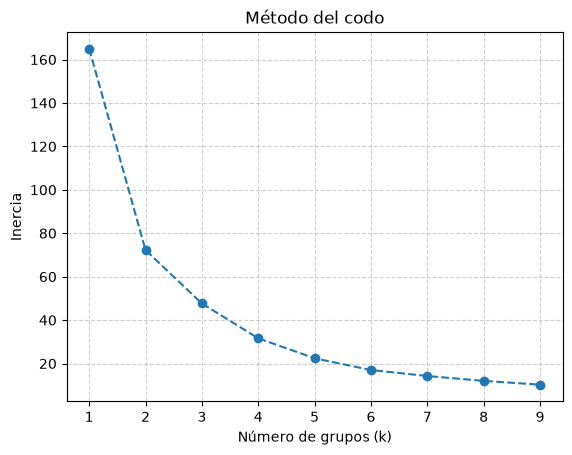

In [6]:
inercia = []
rango_k = range(1, 10)

for k in rango_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(datos)
    inercia.append(modelo.inertia_)

plt.plot(rango_k, inercia, marker="o", linestyle="--")
plt.title("Método del codo")
plt.xlabel("Número de grupos (k)")
plt.ylabel("Inercia")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

### Silueta

El presente gráfico permite confirmar el número de grupos: valores cercanos a 1 indican municipios bien asignados a su grupo.

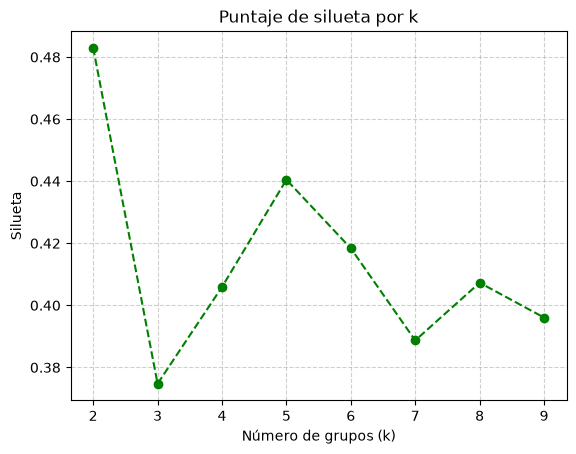

In [7]:
puntajes = []
rango_sil = range(2, 10)

for k in rango_sil:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    grupos = modelo.fit_predict(datos)
    puntajes.append(silhouette_score(datos, grupos))

plt.plot(list(rango_sil), puntajes, marker="o", linestyle="--", color="green")
plt.title("Puntaje de silueta por k")
plt.xlabel("Número de grupos (k)")
plt.ylabel("Silueta")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

**Resultado.** Usando el método del codo, el valor *K* se empieza a estabilizar entre 3 y 4. Para el caso del Silluete Score, el valor *K = 4* es superior a *K=3*. Aun así, teniendo en cuenta la diferencia marginal entre los valores *K* en el Silluete Score, se opta por un valor de `K = 3`, el cual permite una distribución más clara de los perfiles de riesgo eléctrico, y que, como se verá más adelante, es resistente a diferentes semillas del `ramdom_state`.

## Modelo final

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_mpio["cluster"] = kmeans.fit_predict(datos)

perfiles = df_mpio.groupby("cluster").agg(
    municipios=("horas_media", "count"),
    horas_media=("horas_media", "mean"),
    energia_media=("energia_media", "mean"),
    potencia_media=("potencia_media", "mean")
).round(2).sort_values("horas_media")

perfiles

,municipios,horas_media,energia_media,potencia_media
cluster,,,,
0,17,5.62,5595.81,132.52
2,22,10.13,28926.63,6315.66
1,16,20.70,720216.95,190071.14


**Resultados.** Los perfiles se ordenan de menor a mayor disponibilidad: 

1) El clúster ``0`` representa el grupo crítico prioritario, teniendo bajos promedios diarios de prestación y bajas capacidades de generación.

2) El clúster ``2`` contiene un servicio de mejor calidad que el anterior, pero bastante distante de escenarios sin probreza energética, ya que se encuentra por debajo del promedio nacional. 

3) El clúster ``1``, con la menor cantidad de registros, representa al grupo de municipios cuya capacidad de generación y prestración diaria supera con creces a los dos anteriores clústers. Contiene promedios de prestación superiores a las 20 horas diarias.

### Grupos por energía y horas

El presente gráfico permite ver los cuatro grupos separados. El eje de energía va en escala logarítmica porque los consumos van de miles a millones: sin ella, los municipios se amontonan a la izquierda.

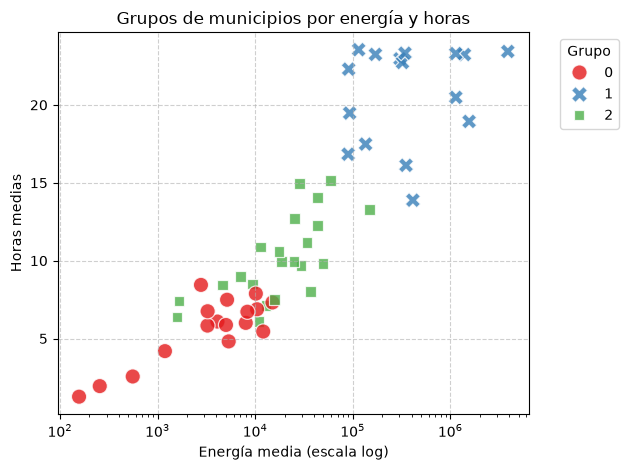

In [9]:
sns.scatterplot(data=df_mpio, x="energia_media", y="horas_media", hue="cluster",
    style="cluster", palette="Set1", s=120, alpha=0.8)
plt.xscale("log")
plt.title("Grupos de municipios por energía y horas")
plt.xlabel("Energía media (escala log)")
plt.ylabel("Horas medias")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Grupo", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Municipios por grupo

In [10]:
for cluster in perfiles.index:
    lista = sorted(df_mpio[df_mpio["cluster"] == cluster].index.tolist())
    print(f"Grupo {cluster} ({len(lista)} municipios):")
    print(", ".join(lista), "\n")

Grupo 0 (17 municipios):
el charco, francisco pizarro, la tola, lópez (micay), magüí, medio atrato, medio san juan, mosquera, olaya herrera, quibdó, riosucio, río quito, santa bárbara, sipí, timbiquí, trinidad, tumaco 

Grupo 2 (22 municipios):
alto baudó, bajo baudó, barrancominas, bojayá, buenaventura, cartagena de indias, cartagena del chairá, carurú, el litoral del san juan, guapi, istmina, novita, nuquí, roberto payán, san andrés de tumaco, san josé del guaviare, san vicente del caguán, taraira, tarapacá, unguía, uribia, vigía del fuerte 

Grupo 1 (16 municipios):
acandí, bahía solano, ciénaga, cumaribo, inírida, juradó, la primavera, leticia, mapiripán, miraflores, mitú, providencia, puerto carreño, puerto leguízamo, puerto nariño, santa rosalía 



### Estabilidad del modelo

El presente análisis permite verificar qué tan sensibles son los grupos al azar inicial: en 5 inicializaciones los tamaños oscilan entre 14-17, 17-18 y 21-24 municipios, con un acuerdo ARI de 0,74 a 0,94 frente a la semilla 42. Existe un núcleo estable en cada perfil y unos municipios frontera que cambian de grupo: la estructura de tres perfiles se mantiene, pero la asignación individual debe leerse con cautela.

In [11]:
referencia = None
for semilla in [42, 0, 7, 99, 123]:
    grupos = KMeans(n_clusters=3, random_state=semilla, n_init=10).fit_predict(datos)
    tamanos = sorted(pd.Series(grupos).value_counts().tolist())
    acuerdo = "-" if referencia is None else round(adjusted_rand_score(referencia, grupos), 3)
    if referencia is None:
        referencia = grupos
    print(f"Semilla {semilla}: tamanos {tamanos} | acuerdo {acuerdo}")

Semilla 42: tamanos [16, 17, 22] | acuerdo -
Semilla 0: tamanos [14, 18, 23] | acuerdo 0.736
Semilla 7: tamanos [14, 17, 24] | acuerdo 0.785
Semilla 99: tamanos [17, 17, 21] | acuerdo 0.943
Semilla 123: tamanos [14, 17, 24] | acuerdo 0.785


## Conclusiones

**1)** Se logra desarrollar un modelo de agrupamiento estable, usando el algoritmo no supervisado `K-means` para la clasificación del riesgo eléctrico de las `ZNI`

**2)** Se identifica al clúster `0` como el grupo crítico, orientado a la atención prioritaria en política pública

**3)** Dos de los tres grupos (Clústers `0`y `2`) presentan escenarios de pobreza energética, cuyos promedios de prestación son inferiores al promedio nacional de las ZNI en 2025 (11 horas). 

**4)** El clúster ``3`` representa al grupo con las capacidades de generación más estables dentro del modelo. Estos municipios constituyen ejemplos de generación en Zonas No Interconectadas, contando con algunas capitales departamentales como Mitú, Puerto Carreño y Leticia. Aquí también se podría incluir a San Andrés, anteriormente excluído debido al peso de su caracterización como Outlier dentro del modelo. 